## 前言
https://codetop.cc/home

力扣 算法 前100 高频考查题 

---

### 215. 数组中的第K个最大元素
> 给定整数数组 nums 和整数 k，请返回数组中第 k 个最大的元素。时间复杂度为 O(n)

思路：在遍历数组的同时维护一个大小为k的最小堆，遍历完成的时候，最小堆的堆首元素就是top-k。那对于小于小堆队首的元素扔掉就好了，没什么用

In [8]:
import heapq

def findKthLargest(nums, k):
    min_head = []
    
    for x in nums:
        if len(min_head)< k:
            heapq.heappush(min_head,x)
        elif x > min_head[0]:  # 当遇到更大的值的时候才入堆
            heapq.heappushpop(min_head, x)
    
    return min_head[0]

nums = [3,2,1,5,6,4]
k = 2
findKthLargest(nums, k)

5

### 3. 无重复字符的最长子串
>给定一个字符串 s ，请你找出其中不含有重复字符的最长子串的长度。

思路：滑动窗口。左侧窗口收缩条件是：遇到在字典中的元素， 右指针是当前数的下标。

疑问：为什么左指针要收缩到最大的呢？因为左指针是不断往右的，用一个max() 防止左指针走回头路  

坑点：判断窗口收缩之前不能更新字典


In [16]:
def lengthOfLongestSubstring(s):
    seen = {}
    
    # 同时获取下标和元素，单不改变元素的值，用enumerate()
    left = -1
    result = 0
    for right, x in enumerate(s):
        if x in seen:   #窗口收缩
            left = max(left , seen[x])
            
        seen[x] = right  #会记录最近的字符出现的位置, 这里当做窗口右指针
        # 记录结果
        result = max(result,right-left)
    return result
# s = "abcabcbb"
s = "abba"
lengthOfLongestSubstring(s)

2

### 72. 编辑距离
>给定两个单词 word1 和 word2， 返回将 word1 转换成 word2 所使用的最少操作数。可以对word1进行的操作有 插入新字符、删除、替换

思路：动态规划。

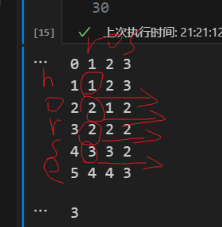

trick: 在处理字符串的时候，往往生成的是下标访问，要养成下标访问的习惯，灵活性更大

In [15]:
def minDistance(word1, word2):
    n, m = len(word1), len(word2)
    
    dp = [[0] * (m +1) for _ in range(n+1)]
    # print(dp)
    
    # 状态转移： 首付首列
    for i in range(1,n+1):
        dp[i][0] = i
    for j in range(1,m+1):
        dp[0][j] = j
    # print(dp)
    
    for i in range(1,n+1):
        for j in range(1,m+1):
            if word1[i-1] == word2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(dp[i-1][j-1], dp[i-1][j] , dp[i][j-1]) + 1
    
    for row in dp:
        print(*row)    
    return dp[n][m]
        
    

word1 = "horse"
word2 = "ros"
minDistance(word1, word2)


0 1 2 3
1 1 2 3
2 2 1 2
3 2 2 2
4 3 3 2
5 4 4 3


3

In [21]:
# 空间优化

def minDistance(word1, word2):
    n, m = len(word1), len(word2)
    
    dp = [0] * (m +1) 
    # print(dp)
    
    # 状态转移： 首行
    for j in range(1,m+1):
        dp[j] = j
    # print(dp)
    
    for i in range(1,n+1):
        leftup = dp[0]
        dp[0] += 1
        for j in range(1,m+1):
            temp = dp[j]
            if word1[i-1] == word2[j-1]:
                dp[j] = leftup
            else:
                dp[j] = min(leftup, dp[j] , dp[j-1]) + 1
            leftup = temp
    # print(*dp)    
    return dp[m]
        
    

word1 = "horse"
word2 = "ros"
minDistance(word1, word2)

3

> python 从矩阵中得到列元素的几种方法
- 列表生成式
- zip(*)
- 转成numpy, 这个支持二维切片取列，python原生的列表不支持

In [9]:
matrix = [[1,2,3],[4,5,6]]
col = [row[1] for row in matrix]  
col

[2, 5]

### 53. 最大子数组和
>给定整数数组 nums，找出一个具有最大和的连续子数组，返回其最大和。

思路：序列动态规划。 如下图，使用正向遍历。dp表空间优化为一个变量，最优子结构是dp[i],历史最大值dp[i]和当前最大值中最大的一个。当前最大值计算:当dp值为负的时候，说明要重新计数了。  
直接求解不出，要用间接求

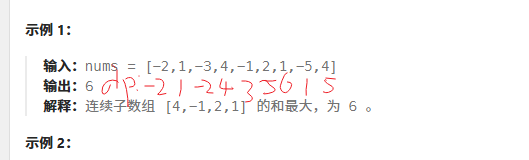
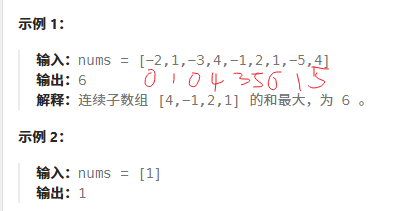

In [2]:
def maxSubArray(nums):
    dp = nums[0]
    result = float('-inf')
    for i in range(1, len(nums)):
        dp = dp+nums[i] if dp > 0 else nums[i]
        # 间接取值，不是最后一个dp[-1]。
        result = max(result,dp)
    
    return result

nums = [-2,1,-3,4,-1,2,1,-5,4]

### 200. 岛屿数量
>

In [ ]:
### 